# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** Nguyễn Huỳnh Nam Quốc - 2453089

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [9]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
class_counts = df["target"].value_counts().sort_index()
class_ratio = df["target"].value_counts(normalize=True).sort_index()

print("Số lượng mẫu của từng lớp:")
display(class_counts)

print("\nTỷ lệ từng lớp:")
display(class_ratio)

print("\nÝ nghĩa target:")
print("0 = Malignant / Ác tính")
print("1 = Benign / Lành tính")

# TODO 1b: Kiểm tra giá trị missing
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("\nSố lượng missing values theo từng cột:")
display(missing_values[missing_values > 0])

print("Tổng số missing values:", total_missing)

Số lượng mẫu của từng lớp:


target
0    212
1    357
Name: count, dtype: int64


Tỷ lệ từng lớp:


target
0    0.372583
1    0.627417
Name: proportion, dtype: float64


Ý nghĩa target:
0 = Malignant / Ác tính
1 = Benign / Lành tính

Số lượng missing values theo từng cột:


Series([], dtype: int64)

Tổng số missing values: 0


**Nhận xét Task 1:**

Bộ dữ liệu có 569 mẫu, trong đó lớp 0 là khối u ác tính và lớp 1 là khối u lành tính. Số lượng mẫu lành tính nhiều hơn mẫu ác tính, cụ thể lớp lành tính chiếm khoảng 62.7%, còn lớp ác tính chiếm khoảng 37.3%.

Dữ liệu hơi mất cân bằng nhưng chưa quá nghiêm trọng. Vì đây là bài toán y khoa, em không nên chỉ nhìn Accuracy mà cần quan tâm thêm Recall, đặc biệt là Recall của lớp 0, vì bỏ sót khối u ác tính sẽ nguy hiểm hơn dự đoán nhầm lành tính thành ác tính.

Kết quả kiểm tra missing values cho thấy dataset không có giá trị khuyết thiếu, nên em có thể chuyển sang bước trực quan hóa và chia dữ liệu.

---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

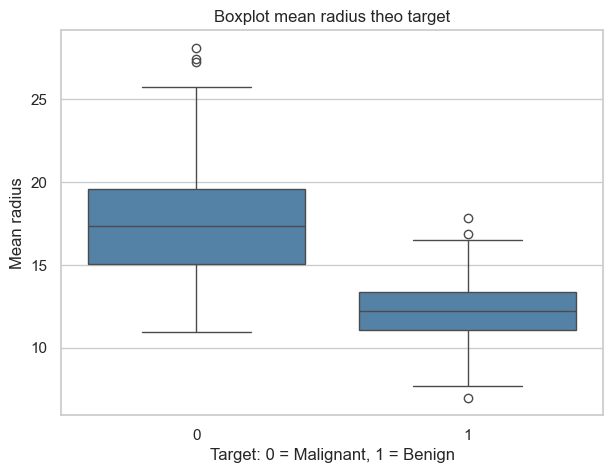

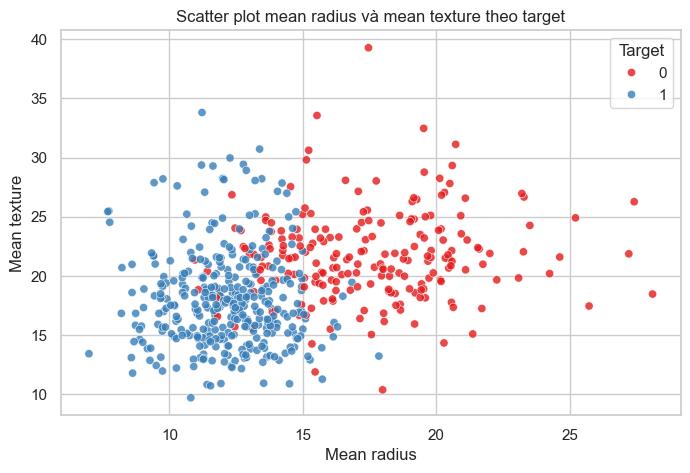

In [10]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="target",
    y="mean radius",
    color="steelblue"
)

plt.title("Boxplot mean radius theo target")
plt.xlabel("Target: 0 = Malignant, 1 = Benign")
plt.ylabel("Mean radius")
plt.show()


# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="target",
    palette="Set1",
    alpha=0.8
)

plt.title("Scatter plot mean radius và mean texture theo target")
plt.xlabel("Mean radius")
plt.ylabel("Mean texture")
plt.legend(title="Target")
plt.show()

**Nhận xét Task 2:**

Ở boxplot, em thấy nhóm khối u ác tính thường có `mean radius` lớn hơn nhóm lành tính. Hai nhóm vẫn có một phần chồng lấn, nhưng xu hướng khác biệt khá rõ.

Ở scatter plot, khi quan sát `mean radius` và `mean texture`, các điểm của hai lớp có xu hướng tách nhau một phần. Những mẫu có `mean radius` lớn thường nghiêng về lớp ác tính, còn những mẫu có `mean radius` nhỏ thường nghiêng về lớp lành tính.

Tuy nhiên, chỉ dùng hai đặc trưng này thì chưa thể phân tách hoàn toàn hai lớp, vì vẫn có vùng bị chồng lấn. Vì vậy mô hình cần dùng thêm nhiều đặc trưng khác để phân loại chính xác hơn.

---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [11]:
# TODO 3a: Tách X, y và chia train/test
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTỷ lệ target toàn bộ:")
display(y.value_counts(normalize=True).sort_index())

print("\nTỷ lệ target train:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTỷ lệ target test:")
display(y_test.value_counts(normalize=True).sort_index())


# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMean của X_train_scaled:")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("\nStd của X_train_scaled:")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))

X_train shape: (426, 30)
X_test shape: (143, 30)
y_train shape: (426,)
y_test shape: (143,)

Tỷ lệ target toàn bộ:


target
0    0.372583
1    0.627417
Name: proportion, dtype: float64


Tỷ lệ target train:


target
0    0.373239
1    0.626761
Name: proportion, dtype: float64


Tỷ lệ target test:


target
0    0.370629
1    0.629371
Name: proportion, dtype: float64


Mean của X_train_scaled:
[-0.  0. -0.  0. -0.]

Std của X_train_scaled:
[1. 1. 1. 1. 1.]


**Nhận xét Task 3:**

Em chia train/test theo tỷ lệ 75/25 và dùng `stratify=y` để giữ tỷ lệ hai lớp gần giống nhau giữa các tập. Điều này quan trọng vì dữ liệu hơi mất cân bằng.

Ở bước scaling, em chỉ `fit_transform` trên `X_train` và chỉ `transform` trên `X_test`. Cách này giúp tránh data leakage, vì thông tin từ tập test không bị dùng khi học tham số chuẩn hóa.

---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

Decision Tree đã được huấn luyện xong.
Feature ở root node: worst radius


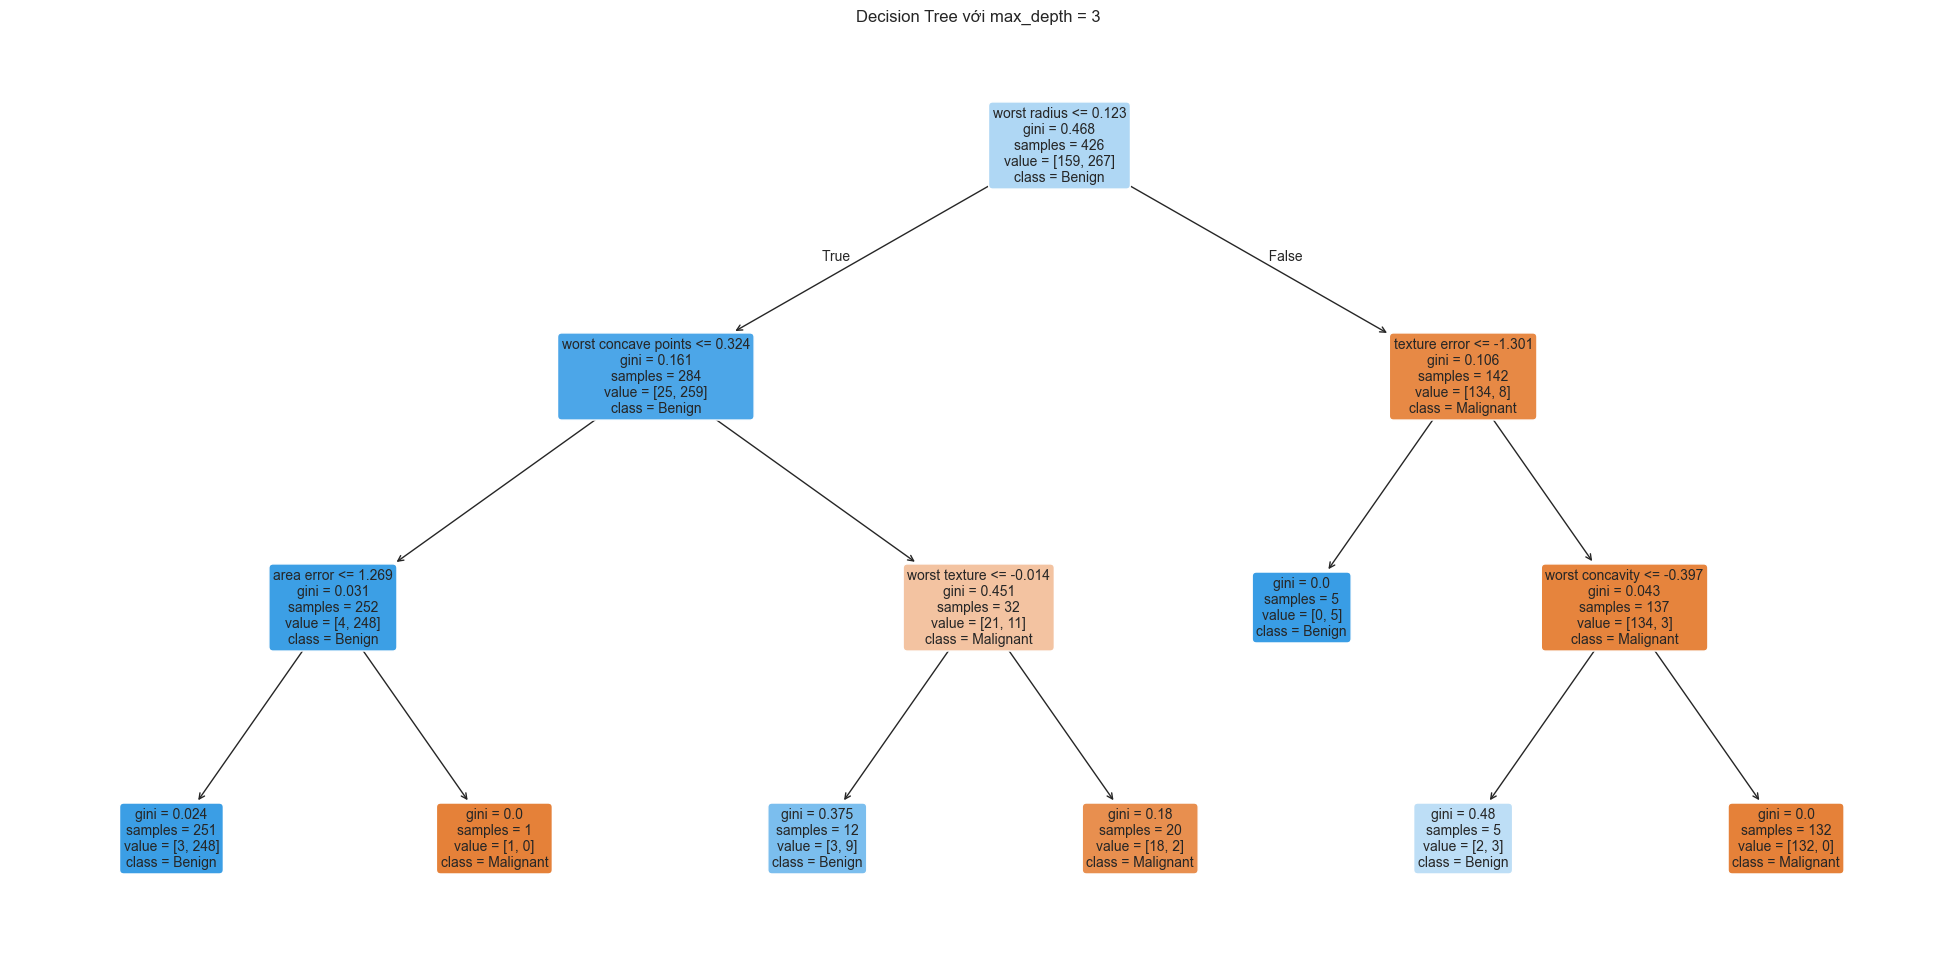

In [12]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

print("Decision Tree đã được huấn luyện xong.")

# Lấy feature ở root node
root_feature_index = dt_model.tree_.feature[0]
root_feature_name = cancer_data.feature_names[root_feature_index]

print("Feature ở root node:", root_feature_name)


# TODO 4b: Vẽ cấu trúc Decision Tree
plt.figure(figsize=(25, 12))

plot_tree(
    dt_model,
    feature_names=cancer_data.feature_names,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree với max_depth = 3")
plt.show()

**Nhận xét Task 4:**

Ở cây của em, nút gốc đang dùng đặc trưng `worst radius` để chia dữ liệu đầu tiên. Đây là một đặc trưng khá hợp lý vì kích thước khối u thường liên quan mạnh đến khả năng khối u là ác tính hay lành tính.

Em nghĩ đây là một trong những đặc trưng quan trọng, vì nó được chọn ngay ở root node, tức là mô hình thấy feature này giúp giảm impurity nhiều nhất ở lần chia đầu tiên. Tuy nhiên, không nên kết luận chỉ một mình `worst radius` là đủ, vì các node phía dưới vẫn dùng thêm nhiều đặc trưng khác để phân loại tốt hơn.

---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

Random Forest đã được huấn luyện xong.


,Feature,Importance
23,worst area,0.149674
27,worst concave points,0.127189
7,mean concave points,0.104650
20,worst radius,0.086963
22,worst perimeter,0.080299
2,mean perimeter,0.080037
6,mean concavity,0.055420
0,mean radius,0.053665
3,mean area,0.044062
13,area error,0.024557


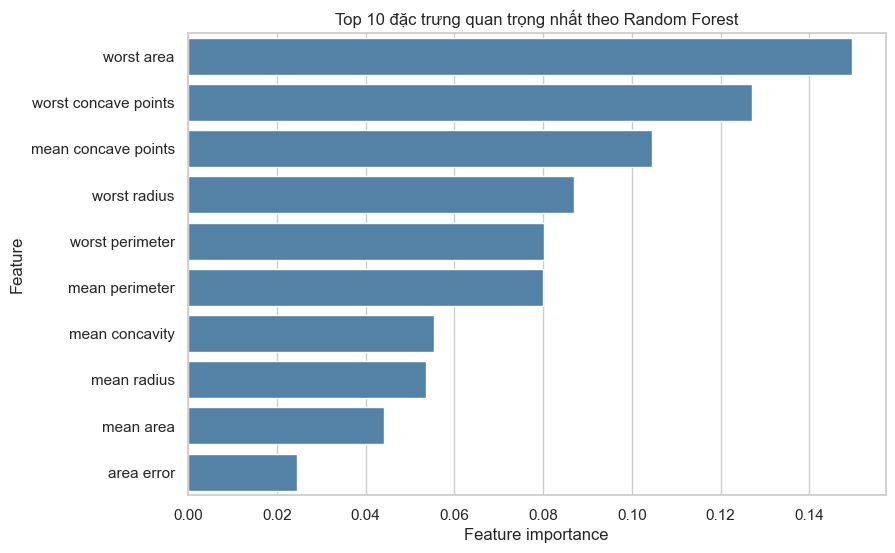

In [13]:
# TODO 5a: Huấn luyện Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest đã được huấn luyện xong.")


# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": cancer_data.feature_names,
    "Importance": importances
})

imp_df = imp_df.sort_values(by="Importance", ascending=False)

top10_features = imp_df.head(10)

display(top10_features)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top10_features,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 10 đặc trưng quan trọng nhất theo Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Nhận xét Task 5:**

Random Forest cho thấy các đặc trưng liên quan đến kích thước và hình dạng khối u như `worst area`, `worst concave points`, `mean concave points`, `worst radius` thường nằm trong nhóm quan trọng nhất.

Điều này hợp lý vì khối u ác tính thường có hình dạng và kích thước bất thường hơn. So với một cây đơn lẻ, Random Forest dùng nhiều cây nên kết quả feature importance ổn định hơn và ít bị phụ thuộc vào một lần chia dữ liệu cụ thể.

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

Classification Report - Random Forest:
               precision    recall  f1-score   support

Malignant (0)       0.96      0.92      0.94        53
   Benign (1)       0.96      0.98      0.97        90

     accuracy                           0.96       143
    macro avg       0.96      0.95      0.95       143
 weighted avg       0.96      0.96      0.96       143



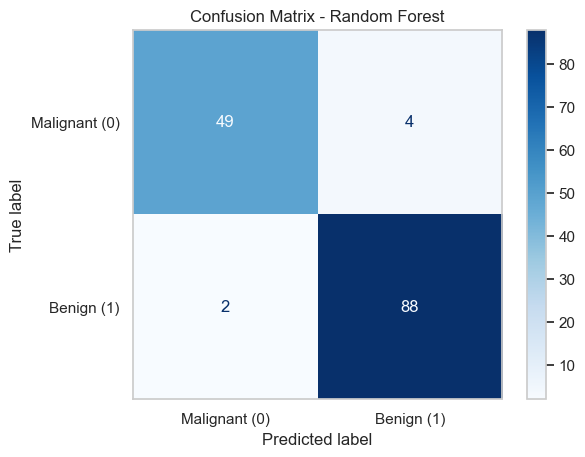

Recall lớp ác tính (0): 0.9245
F1-score lớp ác tính (0): 0.9423
Số ca ác tính bị bỏ sót: 4


In [14]:
# TODO 6a: Dự đoán trên Test set
y_pred_rf = rf_model.predict(X_test_scaled)


# TODO 6b: In Classification Report
print("Classification Report - Random Forest:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Malignant (0)", "Benign (1)"]
    )
)


# TODO 6c: Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant (0)", "Benign (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()

# Tính riêng chỉ số cho lớp 0: Malignant
recall_malignant = recall_score(y_test, y_pred_rf, pos_label=0)
f1_malignant = f1_score(y_test, y_pred_rf, pos_label=0)

# Trong confusion matrix labels=[0,1]:
# cm[0, 1] = thực tế ác tính nhưng dự đoán là lành tính
false_negative_malignant = cm[0, 1]

print("Recall lớp ác tính (0):", round(recall_malignant, 4))
print("F1-score lớp ác tính (0):", round(f1_malignant, 4))
print("Số ca ác tính bị bỏ sót:", false_negative_malignant)

**Đánh giá Task 6 (Business/Medical Insight):**

1. Recall của lớp Ác tính (0) là bao nhiêu? F1-Score là bao nhiêu?
2. Nhìn vào Confusion Matrix, số bệnh nhân bị bỏ sót (thực tế Ác tính nhưng dự đoán Lành tính) là bao nhiêu ca?
3. Nếu bạn là bác sĩ, bạn thà đánh đổi (giảm Precision để tăng Recall) hay muốn giữ độ chuẩn xác chung? Vì sao?

**Đánh giá Task 6 (Business/Medical Insight):**

1. Recall của lớp Ác tính (0) khoảng `0.9245`, nghĩa là mô hình phát hiện được phần lớn các ca ác tính trong tập test. F1-score của lớp Ác tính khoảng `0.9423`, cho thấy mô hình cân bằng khá tốt giữa precision và recall cho lớp nguy hiểm này.

2. Nhìn vào Confusion Matrix, số bệnh nhân bị bỏ sót là `4` ca. Đây là các trường hợp thực tế là ác tính nhưng mô hình lại dự đoán là lành tính. Trong bài toán y khoa, lỗi này rất nguy hiểm vì bệnh nhân có thể không được điều trị kịp thời.

3. Nếu em là bác sĩ, em sẽ ưu tiên tăng Recall của lớp Ác tính, kể cả phải đánh đổi một phần Precision. Lý do là chẩn đoán nhầm lành tính thành ác tính có thể gây lo lắng và cần kiểm tra thêm, nhưng bỏ sót ca ác tính có thể gây hậu quả nghiêm trọng hơn nhiều. Vì vậy với bài toán này, mô hình có Accuracy cao thôi là chưa đủ; em cần quan tâm đặc biệt đến Recall của lớp 0.

Mặc dù mô hình có Accuracy khoảng 96%, em cho rằng kết quả này chưa đủ an toàn để mô hình tự đưa ra chẩn đoán trong thực tế. Trong 53 ca ác tính ở tập test, mô hình vẫn bỏ sót 4 ca, tương đương khoảng 7.55%. Với bài toán ung thư, đây vẫn là rủi ro đáng kể.

Mô hình phù hợp hơn với vai trò hỗ trợ sàng lọc cho bác sĩ. Trước khi triển khai thực tế, cần tiếp tục tối ưu để tăng Recall của lớp ác tính, đánh giá trên nhiều tập dữ liệu độc lập hơn và không nên dùng kết quả của mô hình để thay thế hoàn toàn quyết định chuyên môn của bác sĩ.